# 02 — SQL Analysis

## Purpose
This notebook runs SQL queries against the leads dataset to answer 
the three core business questions of the project.

## Business Questions
1. At which stage of the funnel is the highest volume of potential 
   clients lost?
2. What are the critical operational KPIs and how do they evolve 
   over time?
3. Which operational levers have the greatest impact on the final 
   conversion rate?
## Approach
Queries are written in SQL (SQLite) and executed via Python. 
Each query is also saved as a standalone .sql file in /sql 
for portfolio visibility.

In [144]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

#load cleaned CSV
leads = pd.read_csv('../data/processed/leads_clean.csv')
metrics = pd.read_csv('../data/processed/monthly_metrics.csv')

# create SQLite database in memory
conn = sqlite3.connect(':memory:')

# load DataFrames into SQL tables
leads.to_sql('leads', conn, if_exists='replace', index=False)
metrics.to_sql('monthly_metrics', conn, if_exists='replace', index=False)

print("Database connected and tables loaded successfully.")
print(f"Tables available: leads, monthly_metrics")

Database connected and tables loaded successfully.
Tables available: leads, monthly_metrics


In [145]:
# function
def run_query(query, title=None):
    """Execute a SQL query and return a formatted DataFrame."""
    result = pd.read_sql_query(query, conn)
    if title:
        print(f"\n{'='*50}")
        print(f" {title}")
        print(f"{'='*50}")
    display(result)
    return result

In [146]:
q1 = """
SELECT 
    stage_reached,
    COUNT(*) as total_leads,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM leads), 1) as pct_of_total,
    SUM(CASE WHEN converted = 1 THEN 1 ELSE 0 END) as converted,
    ROUND(AVG(converted) * 100, 1) as conversion_rate_pct
FROM leads
GROUP BY stage_reached
ORDER BY total_leads DESC;
"""

dropoff = run_query(q1, "Q1 — Stage-by-Stage Drop-off")


 Q1 — Stage-by-Stage Drop-off


,stage_reached,total_leads,pct_of_total,converted,conversion_rate_pct
0,Lead,135,35.5,0,0.0
1,Closed_Won,83,21.8,83,100.0
2,Negotiation,64,16.8,0,0.0
3,Qualified,61,16.1,0,0.0
4,Proposal,37,9.7,0,0.0


In [147]:
with open('../sql/funnel_dropoff.sql', 'w') as f:
    f.write(q1)
print("funnel_dropoff.sql saved ✅")

funnel_dropoff.sql saved ✅


In [148]:
q2 = """
SELECT 
    channel,
    COUNT(*) as total_leads,
    SUM(converted) as total_converted,
    ROUND(AVG(converted) * 100, 1) as conversion_rate_pct,
    ROUND(AVG(CASE WHEN deal_value IS NOT NULL 
          THEN deal_value END), 0) as avg_deal_value,
    ROUND(SUM(CASE WHEN converted = 1 
          THEN deal_value ELSE 0 END), 0) as total_revenue
FROM leads
GROUP BY channel
ORDER BY conversion_rate_pct DESC;
"""

channels = run_query(q2, "Q2 — Conversion Rate and Revenue by Channel")


 Q2 — Conversion Rate and Revenue by Channel


,channel,total_leads,total_converted,conversion_rate_pct,avg_deal_value,total_revenue
0,Referral,95,30,31.6,4207.0,131184.0
1,LinkedIn,133,28,21.1,4046.0,118151.0
2,Website,95,18,18.9,4024.0,69438.0
3,Cold_Outreach,57,7,12.3,3686.0,28912.0


In [149]:
with open('../sql/channel_performance.sql', 'w') as f:
    f.write(q2)
print("channel_performance.sql saved ✅")

channel_performance.sql saved ✅


In [150]:
q3 = """
SELECT 
    stage_reached,
    channel,
    ROUND(AVG(days_in_funnel), 1) as avg_days,
    MIN(days_in_funnel) as min_days,
    MAX(days_in_funnel) as max_days,
    COUNT(*) as total_leads
FROM leads
GROUP BY stage_reached, channel
ORDER BY avg_days DESC;
"""

bottleneck = run_query(q3, "Q3 — Bottleneck Analysis: Days in Funnel by Stage and Channel")


 Q3 — Bottleneck Analysis: Days in Funnel by Stage and Channel


,stage_reached,channel,avg_days,min_days,max_days,total_leads
0,Closed_Won,Referral,60.2,40,79,30
1,Closed_Won,LinkedIn,59.5,47,73,28
2,Closed_Won,Cold_Outreach,58.7,45,69,7
3,Closed_Won,Website,57.8,44,76,18
4,Negotiation,Cold_Outreach,57.0,40,75,9
5,Negotiation,Website,54.5,40,74,25
6,Negotiation,LinkedIn,54.4,40,71,21
7,Negotiation,Referral,52.9,36,64,9
8,Proposal,Cold_Outreach,46.3,31,55,6
9,Proposal,Referral,42.7,35,48,9


In [151]:
with open('../sql/bottleneck_analysis.sql', 'w') as f:
    f.write(q3)
print("bottleneck_analysis.sql saved ✅")

bottleneck_analysis.sql saved ✅


In [152]:
q4 = """
SELECT 
    month,
    new_leads,
    total_closed_won,
    ROUND(conversion_rate * 100, 1) as conversion_rate_pct,
    avg_cycle_days,
    revenue
FROM monthly_metrics
ORDER BY month;
"""

kpis = run_query(q4, "Q4 — Monthly KPI Tracker")


 Q4 — Monthly KPI Tracker


,month,new_leads,total_closed_won,conversion_rate_pct,avg_cycle_days,revenue
0,2023-01,19,4,21.1,50,17264
1,2023-02,19,4,21.1,51,16128
2,2023-03,16,3,18.8,53,10107
3,2023-04,16,3,18.8,52,9720
4,2023-05,16,4,25.0,57,13364
5,2023-06,15,3,20.0,59,10200
6,2023-07,19,4,21.1,57,16616
7,2023-08,17,3,17.6,61,11184
8,2023-09,18,4,22.2,62,16508
9,2023-10,13,3,23.1,56,12330


In [153]:
with open('../sql/monthly_kpi_tracker.sql', 'w') as f:
    f.write(q4)
print("monthly_kpi_tracker.sql saved ✅")

monthly_kpi_tracker.sql saved ✅


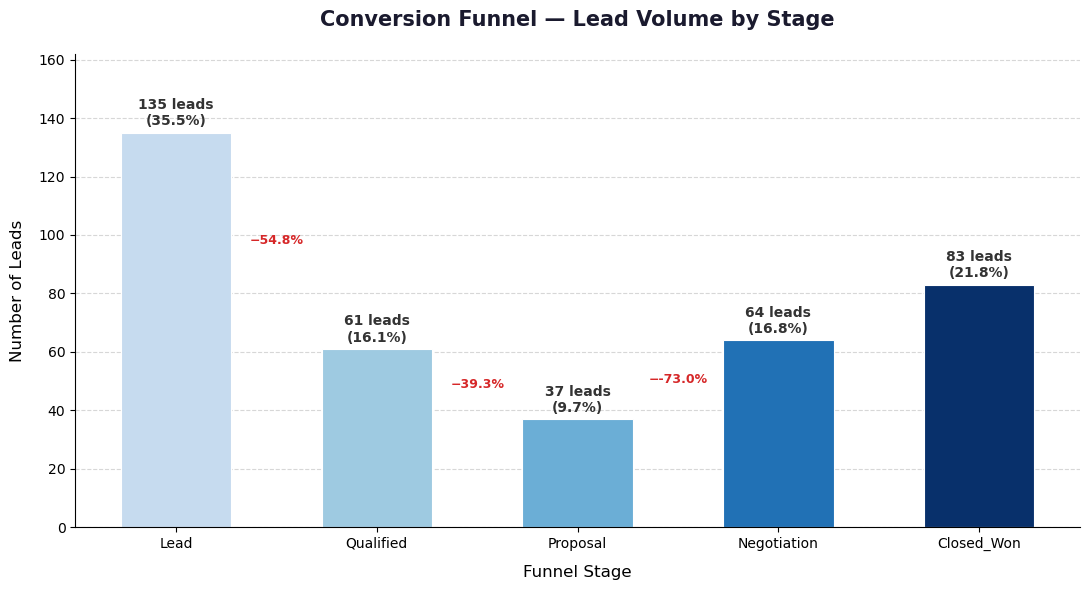

Chart saved to reports/ ✅


In [154]:
# Define funnel order — descending by stage progression
stage_order = ['Lead', 'Qualified', 'Proposal', 'Negotiation', 'Closed_Won']

# Filter and sort by funnel order
dropoff_sorted = (
    dropoff[dropoff['stage_reached'].isin(stage_order)]
    .set_index('stage_reached')
    .reindex(stage_order)
    .reset_index()
)

# Color palette — light to dark to highlight progression
colors = ['#c6dbef', '#9ecae1', '#6baed6', '#2171b5', '#08306b']

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    dropoff_sorted['stage_reached'],
    dropoff_sorted['total_leads'],
    color=colors,
    width=0.55,
    edgecolor='white',
    linewidth=0.8
)

# Add value labels on top of each bar
for bar, row in zip(bars, dropoff_sorted.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{row.total_leads} leads\n({row.pct_of_total}%)",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333333'
    )

# Add drop-off arrows between bars
for i in range(len(dropoff_sorted) - 2):
    x = i + 0.5
    current = dropoff_sorted.iloc[i]['total_leads']
    next_ = dropoff_sorted.iloc[i + 1]['total_leads']
    lost = current - next_
    lost_pct = round(lost * 100 / current, 1)
    ax.annotate(
        f"−{lost_pct}%",
        xy=(x, (current + next_) / 2),
        fontsize=9, color='#d62728',
        ha='center', va='center',
        fontweight='bold'
    )

# Styling
ax.set_title(
    'Conversion Funnel — Lead Volume by Stage',
    fontsize=15, fontweight='bold', pad=20, color='#1a1a2e'
)
ax.set_xlabel('Funnel Stage', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Leads', fontsize=12, labelpad=10)
ax.set_ylim(0, dropoff_sorted['total_leads'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/funnel_dropoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/ ✅")

## SQL Analysis — Key Findings

### Q1 — Funnel Drop-off
- 35.5% of all leads (135) never advanced past the initial 
  Lead stage — representing the largest volume loss in the funnel
- 16.8% of leads (64) reached Negotiation but did not convert — 
  the highest-value loss point given their proximity to closing
- Only 21.8% of total leads (83) converted successfully
- The funnel has two critical intervention points: 
  early qualification and late-stage negotiation

### Q2 — Channel Performance  
- Referral is the highest-converting channel at 31.6% with the 
  highest avg deal value ($4,207) — but volume is limited (95 leads)
- LinkedIn drives the most total revenue ($118,151) through volume 
  despite a mid-range conversion rate of 21.1%
- Cold Outreach has the lowest conversion rate (12.3%) and lowest 
  avg deal value ($3,686) — its ROI relative to effort should 
  be reviewed
- Key insight: optimizing LinkedIn qualification could have the 
  highest revenue impact given its volume advantage

### Q3 — Bottleneck Analysis
- Negotiation is the most expensive bottleneck — leads spent 
  52–57 days in the funnel before stalling, just 3–7 days 
  short of Closed_Won timelines
- Cold_Outreach + Negotiation is the least efficient combination: 
  57 avg days with 9 leads and zero conversions
- Cold_Outreach consistently produces the slowest pipeline 
  across all stages (46.3 days at Proposal, 57.0 at Negotiation)
- Referral leads move through early stages faster, suggesting 
  higher pre-qualification at entry
- Key insight: a late-stage intervention strategy — such as 
  structured follow-up protocols at Negotiation — could recover 
  significant revenue given the time already invested in these leads

### Q4 — KPI Evolution (24 months)
- Conversion rate improved significantly in H2 2024, 
  reaching 27.8% in Sep and 28.6% in Oct–Dec — up from 
  ~20% average in 2023
- Average sales cycle dropped from a peak of 62 days 
  (Sep 2023) to 37 days (Nov 2024) — a ~40% efficiency gain
- Lead volume softened from ~19/month in early 2023 to 
  ~14/month in late 2024, but revenue remained stable 
  due to higher conversion rates
- Key insight: the firm is moving toward a higher-quality, 
  faster-closing pipeline — a positive operational trend 
  that should be protected and accelerated

*These findings will be expanded in the README and executive summary.*